In [19]:
import numpy as np

import matplotlib.pyplot as plt

import jax

import jax.numpy as jnp

from jax import jit, vmap

import torch
import torch.nn as nn
import torch.optim as optim

from collections import deque
from jax import random

In [ ]:

# class Maze:
#     def __init__(self, x,y,z):
#         self.x = x
#         self.y = y
#         self.z = z

#     @staticmethod
#     @jit
#     def cal(x,a):
#         return a+x

#     def calculate(self,a):
#         return self.cal(self.x,a)

# print(Maze(1,2,3).calculate(1))

2


In [3]:

class Maze:
    def __init__(self, maze, start_position, goal_position):
        self.maze = maze
        self.start_position = jnp.array(start_position)
        self.goal_position = jnp.array(goal_position)
        self.reset()

    def reset(self):
        self.current_position = self.start_position
        return self.current_position



    def step(self, action):
        # JAX不允许在原地修改数组，因此我们将位置作为不可变的jnp数组处理
        next_position = self.current_position

        next_position, reward, done = self.step_cal(action, next_position, self.goal_position, self.maze.shape[1], self.maze.shape[0], self.maze[next_position[1], next_position[0]])

        self.current_position = next_position

        return self.current_position, reward, done

    @staticmethod
    @jit
    def step_cal(action, next_position, goal_position, shape_1, shape_0, wall_position_value):
        next_position = jax.lax.cond(action == 0, lambda x: x.at[1].add(-1), lambda x: x, next_position)  # up
        next_position = jax.lax.cond(action == 1, lambda x: x.at[1].add(1), lambda x: x, next_position)   # down
        next_position = jax.lax.cond(action == 2, lambda x: x.at[0].add(-1), lambda x: x, next_position)  # left
        next_position = jax.lax.cond(action == 3, lambda x: x.at[0].add(1), lambda x: x, next_position)   # right

        # 检查是否在迷宫边界内
        within_bounds = (0 <= next_position[0]) & (next_position[0] < shape_1) & \
                        (0 <= next_position[1]) & (next_position[1] < shape_0)

        # 检查是否撞墙
        not_wall = jax.lax.cond(within_bounds,
                                lambda _: wall_position_value == 0,
                                lambda _: False, None)

        # 更新当前位置，如果满足条件
        next_position = jax.lax.cond(not_wall, lambda _: next_position, lambda _: next_position, None)

        done = jnp.array_equal(next_position, goal_position)
        reward = jax.lax.cond(done, lambda _: 1.0, lambda _: -0.1, None)

        return next_position, reward, done

    def render(self):
        maze_copy = self.maze.copy()
        maze_copy = maze_copy.at[self.current_position[1], self.current_position[0]].set(2)
        plt.figure(figsize=(5, 5))
        plt.imshow(maze_copy, cmap='gray')

        plt.text(self.start_position[0], self.start_position[1], 'S', ha='center', va='center', color='red', fontsize=20)
        plt.text(self.goal_position[0], self.goal_position[1], 'G', ha='center', va='center', color='green', fontsize=20)

        plt.show()


In [36]:

class QLearningAgent:
    def __init__(self, maze_env, learning_rate=0.1, discount_factor=0.99, epsilon=0.1,key=random.PRNGKey(0)):
        self.env = maze_env
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.key = key

        # Initialize Q-table with zeros
        maze_shape = self.env.maze.shape
        self.q_table = jnp.zeros((*maze_shape, 4))  # 4 possible actions: up, down, left, right


    def choose_action(self, state, key):
        # 生成一个随机数
        key, subkey = random.split(key)
        rand_num = random.uniform(subkey)

        def explore_action(_):
            # 随机选择一个动作 (探索)
            self.key, subkey = random.split(key)
            return random.randint(subkey, (), 0, 4)

        def exploit_action(_):
            # 选择具有最大Q值的动作 (利用)
            return jnp.argmax(self.q_table[state[1], state[0]])

        action = jax.lax.cond(rand_num < self.epsilon, explore_action, exploit_action, operand=None)
        return action, key



    def update_q_value(self, state, action, reward, next_state, q_table):
        # Get the best Q-value for the next state
        # best_next_action =
        # best_next_q_value = q_table[next_state[1], next_state[0], best_next_action]

        best_next_action, best_next_q_value = self.q_table_find(q_table, next_state)

        # Update Q-value for the current state-action pair
        # current_q_value = q_table[state[1], state[0], action]
        # new_q_value = current_q_value + self.learning_rate * (reward + self.discount_factor * best_next_q_value - current_q_value)
        new_q_value = self.q_table_update(state, self.learning_rate, reward, self.discount_factor, best_next_q_value, q_table, action)

        # 更新 Q-table
        q_table = q_table.at[state[1], state[0], action].set(new_q_value)
        return q_table

    @staticmethod
    @jit
    def q_table_find(q_table, next_state):
        best_next_action = jnp.argmax(q_table[next_state[1], next_state[0]])
        best_next_q_value = q_table[next_state[1], next_state[0], best_next_action]
        return best_next_action, best_next_q_value

    @staticmethod
    @jit
    def q_table_update(state, learning_rate, reward, discount_factor, best_next_q_value, q_table, action):
        current_q_value = q_table[state[1], state[0], action]
        new_q_value = current_q_value + learning_rate * (reward + discount_factor * best_next_q_value - current_q_value)
        return new_q_value

    def train(self, num_episodes=1000):
        for episode in range(num_episodes):
            state = self.env.reset()
            done = False
            step_count = 0
            key = jax.random.PRNGKey(episode)
            reward = 0

            while not done:
                # key, subkey = jax.random.split(key)
                action = self.choose_action(state, key)

                next_state, reward, done = self.env.step(action)
                print(action)
                action = action[0]
                self.q_table = self.update_q_value(state, action, reward, next_state, self.q_table)
                state = next_state
                step_count += 1


            # print(f"Episode {episode+1}: Reached goal in {step_count} steps")


    def run(self):
        state = self.env.reset()
        done = False
        step_count = 0
        key = jax.random.PRNGKey(0)

        while not done:
            # key, subkey = jax.random.split(key)
            action = self.choose_action(state, key)
            next_state, reward, done = self.env.step(action)
            # self.env.render()  # Show the current state of the maze
            state = next_state
            step_count += 1

        print(f"Reached the goal in {step_count} steps!")


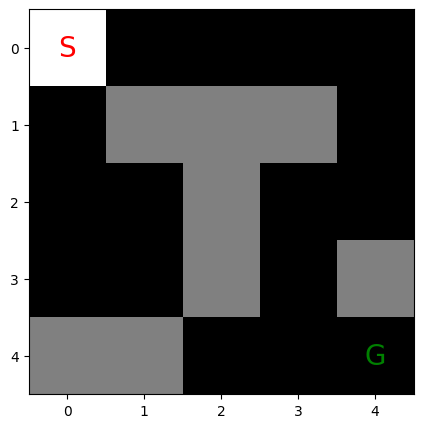

done
(Array(0, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(1, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(2, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(3, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(0, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(1, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(2, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(3, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(0, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(1, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(2, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(3, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(0, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(Array(1, dtype=int32), Array([4146024105,  967050713], dtype=uint32))
(

KeyboardInterrupt: 

In [37]:
maze_layout = jnp.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 1],
    [1, 1, 0, 0, 0]
])

maze = Maze(maze_layout, (0, 0), (4, 4))
maze.render()

maze_env = Maze(maze_layout, (0, 0), (4, 4))
# Create a QLearningAgent instance
agent = QLearningAgent(maze_env)
print("done")
# Train the agent
agent.train(num_episodes=1000)

# Run the trained agent
agent.run()